Домашнее задание по машинному обучению. Никитин Илья М06-509а, МФТИ 

**Непараметрическая регрессия**

- Набор данных: 	car https://www.openml.org/d/40975


***Шаги***
1. Сведение к задаче регрессии и обработка данных. Перейдите от задачи классификации к задаче регрессии, используя OneHot преобразование
2. Реализация алгоритма и настройка гиперпараметров, анализ результатов.
Реализуйте алгоритм решения задачи непареметрической регрессии при помощи ядерного сглаживания Надарая-Ватсона
3. Используйте Leave-One-Out перекрёстную проверку для настройки алгоритма. 
Критерием качества является F-мера. Для её подсчёта потребуется определить максимальную компоненту результирующего вектора целевых признаков, полученных из One-Hot преобразования, после применения очередной конфигурации алгоритма непараметрической регрессии (алгоритм с одной из комбинаций гиперпараметров).
4. Для лучшей найденной комбинации гиперпараметров постройте графики зависимости F-меры от числа ближайших соседей или ширины окна (при фиксированных лучших значениях прочих гиперпараметров). 

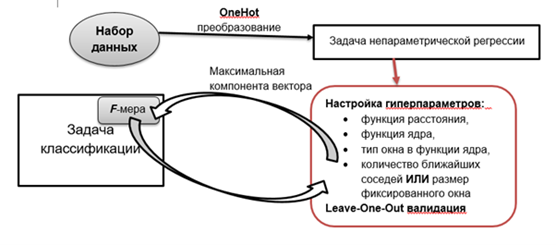

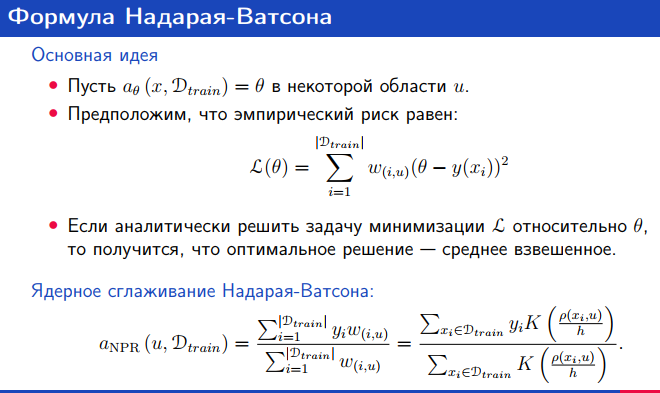

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import f1_score
from scipy.spatial.distance import pdist, cdist

In [197]:
data = arff.loadarff('php2jDIhh.arff')
type(data), data

(tuple,
 (array([(b'vhigh', b'vhigh', b'2', b'2', b'small', b'low', b'unacc'),
         (b'vhigh', b'vhigh', b'2', b'2', b'small', b'med', b'unacc'),
         (b'vhigh', b'vhigh', b'2', b'2', b'small', b'high', b'unacc'), ...,
         (b'low', b'low', b'5more', b'more', b'big', b'low', b'unacc'),
         (b'low', b'low', b'5more', b'more', b'big', b'med', b'good'),
         (b'low', b'low', b'5more', b'more', b'big', b'high', b'vgood')],
        shape=(1728,), dtype=[('buying', 'S5'), ('maint', 'S5'), ('doors', 'S5'), ('persons', 'S4'), ('lug_boot', 'S5'), ('safety', 'S4'), ('class', 'S5')]),
  Dataset: 'car_df'
  	buying's type is nominal, range is ('vhigh', 'high', 'med', 'low')
  	maint's type is nominal, range is ('vhigh', 'high', 'med', 'low')
  	doors's type is nominal, range is ('2', '3', '4', '5more')
  	persons's type is nominal, range is ('2', '4', 'more')
  	lug_boot's type is nominal, range is ('small', 'med', 'big')
  	safety's type is nominal, range is ('low', 'med', 'h

In [198]:
df = pd.DataFrame(data[0])
df = df.applymap(lambda x: x.decode('utf-8'))
df.head(2)

C:\Users\ilya\AppData\Local\Temp\ipykernel_6160\2511475108.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8'))


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc


In [199]:
df.info() # нет нуллов, хорошо

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [202]:
y = df['class']
X = df.drop(columns = ['class'])
ohe_y = OneHotEncoder(sparse_output= False)
y_ohe = ohe_y.fit_transform(y.values.reshape(-1, 1))

ohe_x= OneHotEncoder(sparse_output=False)
X_ohe = ohe_x.fit_transform(X)

X_ohe = StandardScaler().fit_transform(X_ohe) 

In [203]:
X_ohe

array([[-0.57735027, -0.57735027, -0.57735027, ..., -0.70710678,
         1.41421356, -0.70710678],
       [-0.57735027, -0.57735027, -0.57735027, ..., -0.70710678,
        -0.70710678,  1.41421356],
       [-0.57735027, -0.57735027, -0.57735027, ...,  1.41421356,
        -0.70710678, -0.70710678],
       ...,
       [-0.57735027,  1.73205081, -0.57735027, ..., -0.70710678,
         1.41421356, -0.70710678],
       [-0.57735027,  1.73205081, -0.57735027, ..., -0.70710678,
        -0.70710678,  1.41421356],
       [-0.57735027,  1.73205081, -0.57735027, ...,  1.41421356,
        -0.70710678, -0.70710678]], shape=(1728, 21))

In [204]:
# тут пропишем несколько функция для НВ, чтобы потом искать

def euclidian(a, b):
    return np.linalg.norm(a - b)
def manhattane(a, b):
    return np.sum(np.abs(a - b))

def chebishev(a, b):
    return np.max(np.abs(a-b))

# def uniform_kernel(a):
#     if np.abs(a) < 1:
#         return 0.5
#     else:
#         return 0

# def triangular_kernel(a):
#     if np.abs(a) < 1:
#         return (1 - abs(a))
#     else:
#         return 0

# def epanechnikov_kernel(a):
#     if np.abs(a) < 1:
#         return 0.75 * (1 - a**2)
#     else:
#         return 0

# def quartic_kernel(a):
#     if np.abs(a) < 1:
#         return (15 * (1 - a**2)**2) / 16
#     else:
#         return 0

# Пришлось переписать, очень очень долго выполнялось 
def uniform_kernel(a):
    a = np.asarray(a) # numpy -самый оптимизированный
    return 0.5 *(np.abs(a) < 1).astype(float)

def triangular_kernel(a):
    a = np.asarray(a)
    return np.maximum(1 - np.abs(a), 0)

def epanechnikov_kernel(a):
    a = np.asarray(a)
    return 0.75 * (1 - a**2) * (np.abs(a) < 1) # так могу сделать один return))

def quartic_kernel(a):
    a = np.asarray(a)
    return (15 * (1 - a**2)**2 / 16) * (np.abs(a) < 1)

In [205]:
def nadaraya_vatson(y_train, distances, kernel_func, window, h=None, k=None):
    ''' Функция Надарая-Ватсона
    distances вектор расст без i-го объекта
    h=None, k=None для window="variable"
    '''
    if window =="variable":
        d = np.sort(distances)
        if k >= len(d):
            h = d[-1]  # the largest
        else:
            h = d[k- 1]  # просто по порядку к-ый
    if h <= 0:
        return np.mean(y_train, axis=0)

    znamenatel = kernel_func(distances / h)
    if np.sum(znamenatel) == 0:
        K = np.mean(y_train, axis=0)
    else:
        K = np.dot(znamenatel, y_train) / np.sum(znamenatel)
    return K

In [206]:
def leave_one_out(X, y, dist_matrix,kernel_func, window, k=None,h=None):
    y_true, y_pred = [], []
    n = len(X)
    for i in range(len(X)):
        mask = np.arange(n) != i
        distances = dist_matrix[i][mask]
        y_train = np.delete(y, i, axis=0)
        pred = nadaraya_vatson(y_train, distances, kernel_func, window, h, k)

        y_true.append(np.argmax(y[i]))
        
        y_pred.append(np.argmax(pred))

    return f1_score(y_true, y_pred, average='macro')

In [207]:
# закинем в словари для удобства
n = len(X_ohe)

sqrt_n= np.sqrt(n)
k_values = range(1, int(sqrt_n) + 1)

distance_type = {
    'euclidian': euclidian,
    'manhattane': manhattane,
    'chebishev': chebishev}
kernel_type = {
    'uniform': uniform_kernel,
    'triangular': triangular_kernel,
    'epanechnikov': epanechnikov_kernel,
    'quartic': quartic_kernel}

In [208]:
# немного жульничаем, чтобы не реализовывать нахождение максимумов из всевозможных пар руками
max_distance = {
    'euclidian': np.max(pdist(X_ohe, metric='euclidean')),
    'manhattane': np.max(pdist(X_ohe, metric='cityblock')),
    'chebishev': np.max(pdist(X_ohe, metric='chebyshev'))}

In [209]:
h_values_dict = {}
for name in max_distance:
    d = max_distance[name]
    step = d/sqrt_n
    h_values = np.arange(d / sqrt_n, d + step, step)
    h_values_dict[name] = h_values

In [210]:
h_values_dict

{'euclidian': array([0.18477965, 0.3695593 , 0.55433895, 0.73911859, 0.92389824,
        1.10867789, 1.29345754, 1.47823719, 1.66301684, 1.84779649,
        2.03257613, 2.21735578, 2.40213543, 2.58691508, 2.77169473,
        2.95647438, 3.14125403, 3.32603367, 3.51081332, 3.69559297,
        3.88037262, 4.06515227, 4.24993192, 4.43471157, 4.61949121,
        4.80427086, 4.98905051, 5.17383016, 5.35860981, 5.54338946,
        5.72816911, 5.91294875, 6.0977284 , 6.28250805, 6.4672877 ,
        6.65206735, 6.836847  , 7.02162664, 7.20640629, 7.39118594,
        7.57596559, 7.76074524]),
 'manhattane': array([ 0.63951955,  1.2790391 ,  1.91855865,  2.5580782 ,  3.19759776,
         3.83711731,  4.47663686,  5.11615641,  5.75567596,  6.39519551,
         7.03471506,  7.67423461,  8.31375417,  8.95327372,  9.59279327,
        10.23231282, 10.87183237, 11.51135192, 12.15087147, 12.79039102,
        13.42991057, 14.06943013, 14.70894968, 15.34846923, 15.98798878,
        16.62750833, 17.267027

In [211]:
dist_matrices = {} # попарные рассотяния (которые вычисляли выше встроеннойц функцией,
# будем хранить вне цикла, чтобы не считать их внутри, это очень ускорит)
for dist_name in distance_type.keys():
    metric = {'euclidian': 'euclidean','manhattane': 'cityblock', 'chebishev': 'chebyshev'}[dist_name]
    dist_matrices[dist_name] = cdist(X_ohe, X_ohe, metric=metric)
    
best_score = - np.inf # чтобы все было лучше
best_params=None

results = []

In [212]:
for dist_name, dist_func in distance_type.items():         
    dist_matrix = dist_matrices[dist_name]                
    zapusk = 0
    for kernel_name, kernel_func in kernel_type.items():
     # переменная ширина
        for k in k_values:
            score = leave_one_out(
                X_ohe, y_ohe,
                dist_matrix,          
                kernel_func,
                window='variable',
                k=k)
            results.append((dist_name, kernel_name, 'variable', k, score))

            if score > best_score:
                best_score = score
                best_params = (dist_name, kernel_name, 'variable', k)

        # фиксированное h, сравним с перем
        for h in h_values_dict[dist_name]:
            score = leave_one_out(
                X_ohe, y_ohe,
                dist_matrix,
                kernel_func,
                window='fixed',
                h=h)
            results.append((dist_name, kernel_name, 'fixed', h, score))

            if score > best_score:
                best_score = score
                best_params = (dist_name, kernel_name, 'fixed', h)
        print(zapusk, kernel_name, kernel_func)
        zapusk += 1 # минимальная отладка

0 uniform <function uniform_kernel at 0x0000019F3D553880>
1 triangular <function triangular_kernel at 0x0000019F3D551D00>
2 epanechnikov <function epanechnikov_kernel at 0x0000019F3D5511C0>
3 quartic <function quartic_kernel at 0x0000019F3D551120>
0 uniform <function uniform_kernel at 0x0000019F3D553880>
1 triangular <function triangular_kernel at 0x0000019F3D551D00>
2 epanechnikov <function epanechnikov_kernel at 0x0000019F3D5511C0>
3 quartic <function quartic_kernel at 0x0000019F3D551120>
0 uniform <function uniform_kernel at 0x0000019F3D553880>
1 triangular <function triangular_kernel at 0x0000019F3D551D00>
2 epanechnikov <function epanechnikov_kernel at 0x0000019F3D5511C0>
3 quartic <function quartic_kernel at 0x0000019F3D551120>


In [213]:
best_params, best_score

(('euclidian', 'epanechnikov', 'variable', 28), 0.8298672676103004)

In [214]:
best_dist, best_kernel,best_window, best_param = best_params
final = [] # only besst model
for item in results:
    dist_name, kernel_name,window, param, score = item
    if (dist_name == best_dist and kernel_name == best_kernel and window == best_window):
        final.append((param, score))
final.sort(key=lambda x: x[0])

In [215]:
final

[(1, 0.2059223961878829),
 (2, 0.2059223961878829),
 (3, 0.28715093630654015),
 (4, 0.35414660167567147),
 (5, 0.3821584452318524),
 (6, 0.4281415646016238),
 (7, 0.5217395834509349),
 (8, 0.5217395834509349),
 (9, 0.5217395834509349),
 (10, 0.5217395834509349),
 (11, 0.5217395834509349),
 (12, 0.5217395834509349),
 (13, 0.5217395834509349),
 (14, 0.5217395834509349),
 (15, 0.5217395834509349),
 (16, 0.8220290398854927),
 (17, 0.8220290398854927),
 (18, 0.8207332359037623),
 (19, 0.8207332359037623),
 (20, 0.8207332359037623),
 (21, 0.8207332359037623),
 (22, 0.8207332359037623),
 (23, 0.8207332359037623),
 (24, 0.8207332359037623),
 (25, 0.8207332359037623),
 (26, 0.8207332359037623),
 (27, 0.8207332359037623),
 (28, 0.8298672676103004),
 (29, 0.8298672676103004),
 (30, 0.8298672676103004),
 (31, 0.8298672676103004),
 (32, 0.8298672676103004),
 (33, 0.8298672676103004),
 (34, 0.8298672676103004),
 (35, 0.8298672676103004),
 (36, 0.8298672676103004),
 (37, 0.8298672676103004),
 (38, 0.

Лучше получилась модель с соседями (чем с шириной окна)

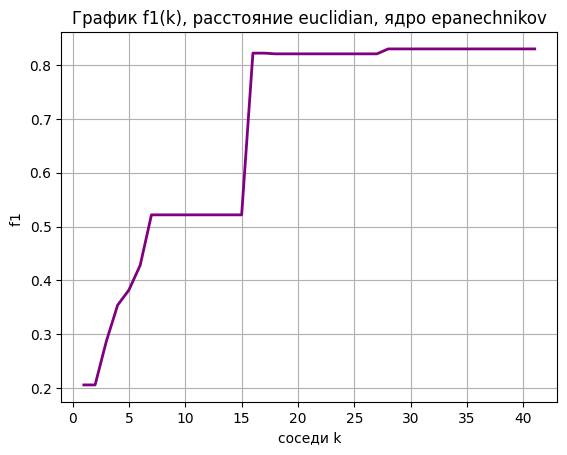

In [216]:
xx = [x[0] for x in final]
yy = [x[1] for x in final]

plt.plot(xx, yy,color='purple', linewidth=2)
plt.xlabel('соседи k')
plt.ylabel('f1 ')
plt.title(f'График f1(k), pасстояние {best_dist}, ядро {best_kernel}')
plt.grid(True)
plt.show();

Остается постоянной с ~28 соседей (или уже можно брать с 16 соседей, если не критично небольшое улучшение)